In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer   
import seaborn as sns

In [2]:
df_final = pd.read_csv('../data/df_final.csv')

<p style = 'color:blue;font-weight:bold' >
Preprocessing
<p>


In [3]:
print(df_final[['budget', 'revenue', 'runtime']].describe())
print((df_final[['budget', 'revenue']] == 0).sum())

             budget       revenue      runtime
count  9.621000e+03  9.621000e+03  9621.000000
mean   1.899194e+07  5.677176e+07   103.961023
std    3.435458e+07  1.396901e+08    24.437396
min    0.000000e+00  0.000000e+00     0.000000
25%    0.000000e+00  0.000000e+00    92.000000
50%    4.300000e+06  8.000000e+06   101.000000
75%    2.300000e+07  4.740557e+07   115.000000
max    3.790000e+08  2.923706e+09   583.000000
budget     3299
revenue    2732
dtype: int64


<p style = 'color:blue; font-weight:bold'>
Correlation Matrix
<p>

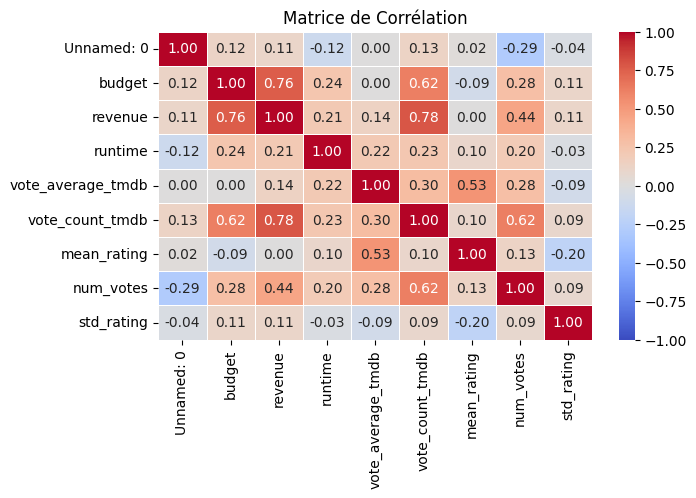

In [4]:
cols_to_corr = df_final.select_dtypes(include=['float64', 'int64']).drop(columns=['movieId'], errors='ignore')

plt.figure(figsize=(7, 4))

sns.heatmap(cols_to_corr.corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0, vmin=-1, vmax=1, linewidths=0.5)

plt.title('Matrice de Corrélation')
plt.show()

In [5]:
df_mining = df_final[['title', 'genres']]
df_mining.head()

,title,genres
0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,Jumanji (1995),Adventure|Children|Fantasy
2,Grumpier Old Men (1995),Comedy|Romance
3,Waiting to Exhale (1995),Comedy|Drama|Romance
4,Father of the Bride Part II (1995),Comedy


In [6]:
df_mining['genres'] = df_mining['genres'].apply(lambda x:x.split('|'))
df_mining.head()
mlb = MultiLabelBinarizer()
X_genres = mlb.fit_transform(df_final['genres'].str.split('|'))

In [7]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules

te = TransactionEncoder()
te_ary = te.fit(df_mining['genres']).transform(df_mining['genres'])
df_mining_transaction = pd.DataFrame(te_ary, columns=te.columns_)
df_mining_transaction = df_mining_transaction.drop(columns=['(no genres listed)'])
df_mining_transaction.head()

,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,False,True,True,True,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False
3,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False
4,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
frequent_itemsets = fpgrowth(df_mining_transaction, min_support=0.01, use_colnames=True)
print(frequent_itemsets)

     support                               itemsets
0   0.385547                    frozenset({Comedy})
1   0.129645                 frozenset({Adventure})
2   0.079963                   frozenset({Fantasy})
3   0.068158                  frozenset({Children})
4   0.062718                 frozenset({Animation})
..       ...                                    ...
87  0.016629  frozenset({Thriller, Sci-Fi, Action})
88  0.030589                frozenset({War, Drama})
89  0.013139               frozenset({Action, War})
90  0.011907            frozenset({Drama, Musical})
91  0.017245           frozenset({Comedy, Musical})

[92 rows x 2 columns]


In [9]:
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2, num_itemsets=len(df_mining_transaction.index))

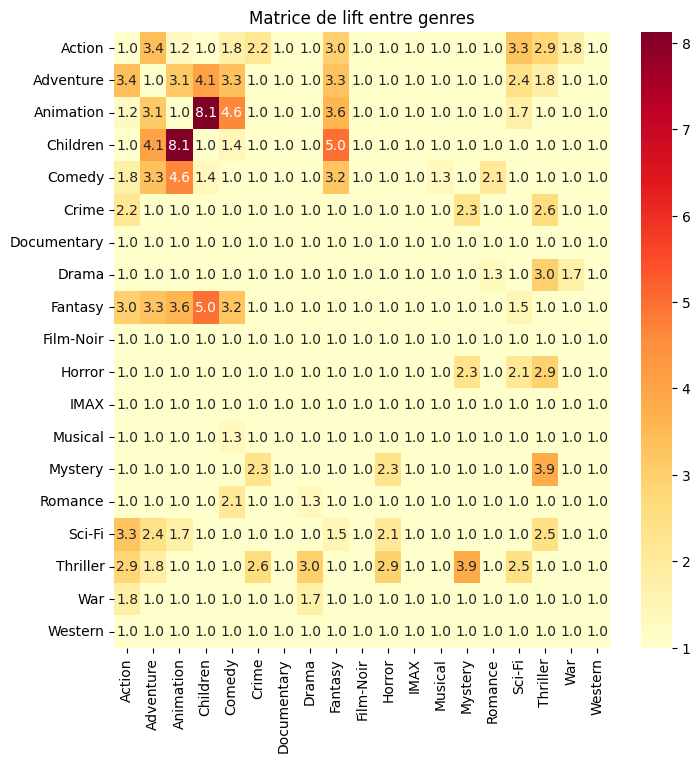

In [10]:
genres = df_mining_transaction.columns.tolist()
lift_matrix = pd.DataFrame(np.ones((len(genres), len(genres))), index=genres, columns=genres)

for _, row in rules.iterrows():
    ant = list(row['antecedents'])[0]
    con = list(row['consequents'])[0]
    lift_matrix.loc[ant, con] = row['lift']
    lift_matrix.loc[con, ant] = row['lift']

plt.figure(figsize=(8,8))
sns.heatmap(lift_matrix, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("Matrice de lift entre genres")
plt.savefig("lift_matrix1.png", dpi=300, bbox_inches='tight')
plt.show()

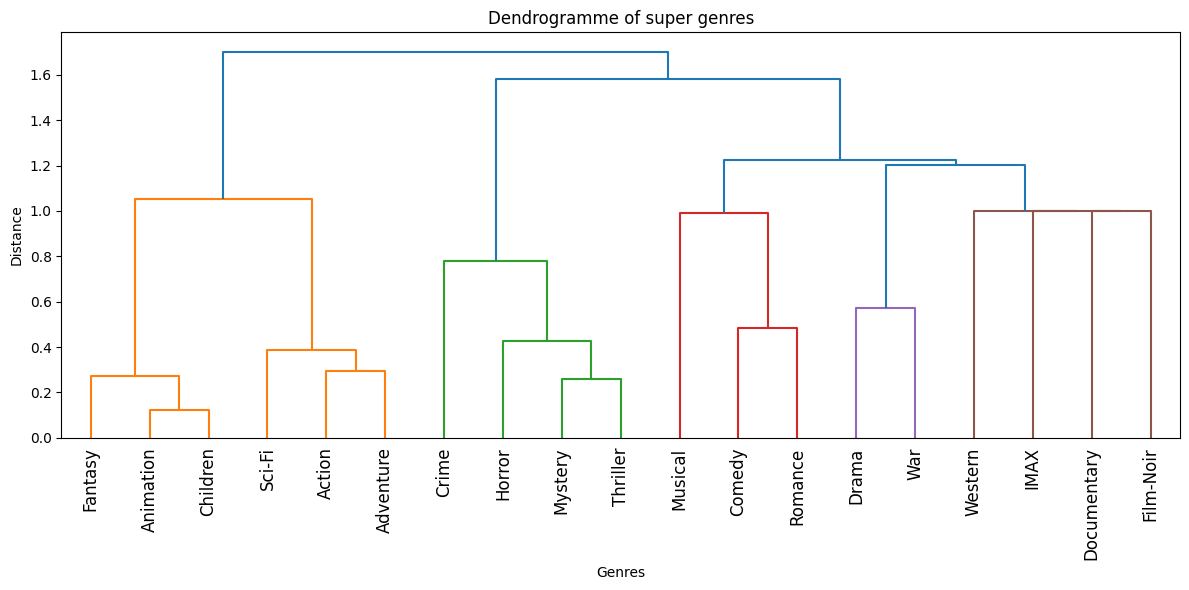

In [11]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

distance_matrix = 1 / lift_matrix #(converting Lift to distance)
condensed = squareform(distance_matrix.values, checks=False)
linked = linkage(condensed, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(linked, labels=lift_matrix.columns.tolist(), leaf_rotation=90)
plt.title("Dendrogramme of super genres")
plt.xlabel("Genres")
plt.ylabel("Distance")
plt.tight_layout()
plt.savefig("dendrogramme.png", dpi=300, bbox_inches='tight')
plt.show()

In [12]:
from scipy.cluster.hierarchy import fcluster
n_clusters = 8
cluster_labels = fcluster(linked, n_clusters, criterion='maxclust')
genre_to_cluster = dict(zip(lift_matrix.columns.tolist(), cluster_labels))
print(genre_to_cluster)


genres_isoles = ['Musical', 'Western', 'IMAX', 'Documentary', 'Film-Noir', 'Romance', 'War']
def assign_super_genre(genres_list):
    if not genres_list:
        return "Autres"
    
    genres_non_isoles = [g for g in genres_list if g not in genres_isoles and g in genre_to_cluster]
    
    if genres_non_isoles:
        clusters = [genre_to_cluster[g] for g in genres_non_isoles]
        majority = max(set(clusters), key=clusters.count)
        return majority

df_mining['super_genre'] = df_mining['genres'].apply(assign_super_genre)

{'Action': np.int32(2), 'Adventure': np.int32(2), 'Animation': np.int32(1), 'Children': np.int32(1), 'Comedy': np.int32(4), 'Crime': np.int32(3), 'Documentary': np.int32(6), 'Drama': np.int32(5), 'Fantasy': np.int32(1), 'Film-Noir': np.int32(6), 'Horror': np.int32(3), 'IMAX': np.int32(6), 'Musical': np.int32(4), 'Mystery': np.int32(3), 'Romance': np.int32(4), 'Sci-Fi': np.int32(2), 'Thriller': np.int32(3), 'War': np.int32(5), 'Western': np.int32(6)}


In [13]:
print(df_mining['super_genre'].value_counts())

super_genre
4.0    2211
3.0    2203
2.0    2029
5.0    1656
1.0    1165
Name: count, dtype: int64


In [14]:
for genre, cluster in genre_to_cluster.items():
    print(f"{genre} -> Cluster {cluster}")

Action -> Cluster 2
Adventure -> Cluster 2
Animation -> Cluster 1
Children -> Cluster 1
Comedy -> Cluster 4
Crime -> Cluster 3
Documentary -> Cluster 6
Drama -> Cluster 5
Fantasy -> Cluster 1
Film-Noir -> Cluster 6
Horror -> Cluster 3
IMAX -> Cluster 6
Musical -> Cluster 4
Mystery -> Cluster 3
Romance -> Cluster 4
Sci-Fi -> Cluster 2
Thriller -> Cluster 3
War -> Cluster 5
Western -> Cluster 6


In [15]:
df_mining_supergenre = df_final.copy()
df_mining_supergenre = df_mining_supergenre.drop(columns = ['genres'])
df_mining_supergenre['super_genre'] = df_mining['super_genre'].values
df_mining_supergenre.to_csv('supergenres.csv', index = True)